In [ ]:
# Import Required Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("sales_data.csv")

In [3]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

df.head()

,Date,Sales,Promotion,DayOfWeek
0,2024-01-01,204.21,0,1
1,2024-01-02,256.30,1,2
2,2024-01-03,216.38,0,3
3,2024-01-04,201.28,0,4
4,2024-01-05,182.48,0,5


In [ ]:
# Basic Info & Missing Values


print("Dataset Shape:", df.shape)
print("\nData Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

Dataset Shape: (366, 4)

Data Types:

Date         datetime64[ns]
Sales               float64
Promotion             int64
DayOfWeek             int64
dtype: object

Missing Values:

Date         0
Sales        0
Promotion    0
DayOfWeek    0
dtype: int64


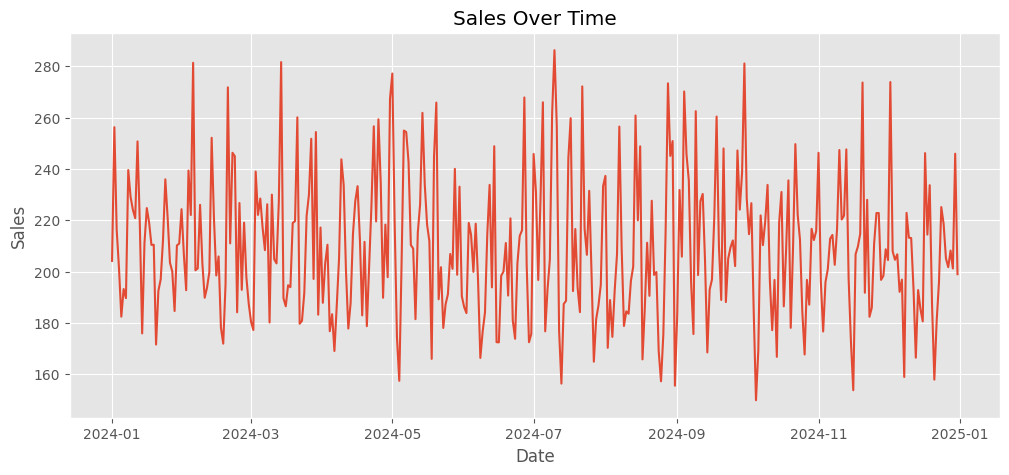

In [ ]:
# Sales Trend Over Time

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Sales'])
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

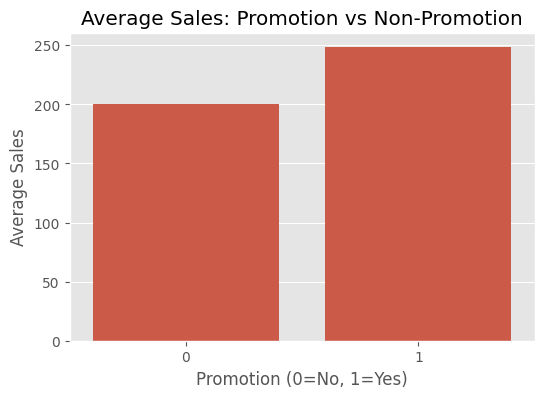

Promotion
0    200.383017
1    248.267606
Name: Sales, dtype: float64


In [ ]:
# Promotion vs Non-Promotion

promo_sales = df.groupby("Promotion")["Sales"].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=promo_sales.index, y=promo_sales.values)
plt.title("Average Sales: Promotion vs Non-Promotion")
plt.xlabel("Promotion (0=No, 1=Yes)")
plt.ylabel("Average Sales")
plt.show()

print(promo_sales)

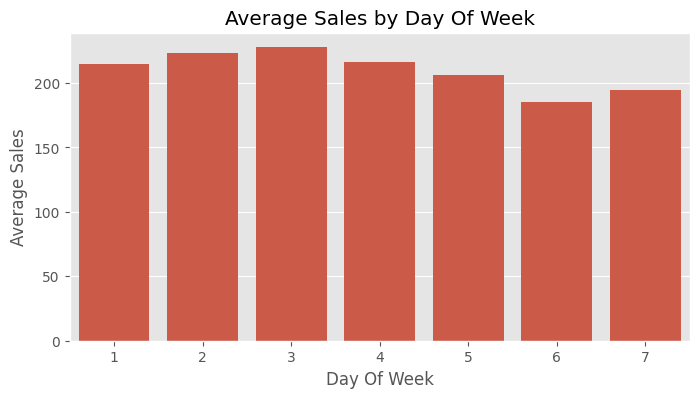

DayOfWeek
1    214.437925
2    223.161698
3    227.656923
4    216.139231
5    206.321346
6    184.999423
7    194.637115
Name: Sales, dtype: float64


In [ ]:
# Sales by DayOfWeek

dow_sales = df.groupby("DayOfWeek")["Sales"].mean()

plt.figure(figsize=(8,4))
sns.barplot(x=dow_sales.index, y=dow_sales.values)
plt.title("Average Sales by Day Of Week")
plt.xlabel("Day Of Week")
plt.ylabel("Average Sales")
plt.show()

print(dow_sales)

In [ ]:
# Feature Engineering

df['lag_1'] = df['Sales'].shift(1)
df['lag_7'] = df['Sales'].shift(7)
df['rolling_mean_7'] = df['Sales'].rolling(7).mean()

df = df.dropna()

df.head()

,Date,Sales,Promotion,DayOfWeek,lag_1,lag_7,rolling_mean_7
7,2024-01-08,239.61,1,1,189.72,204.21,211.288571
8,2024-01-09,229.13,0,2,239.61,256.30,207.407143
9,2024-01-10,224.11,0,3,229.13,216.38,208.511429
10,2024-01-11,220.87,0,4,224.11,201.28,211.310000
11,2024-01-12,250.77,1,5,220.87,182.48,221.065714


In [ ]:
# Train-Test Split

test_size = 30

train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

features = ['Promotion', 'DayOfWeek', 'lag_1', 'lag_7', 'rolling_mean_7']
target = 'Sales'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (329, 5)
Test Shape: (30, 5)


In [15]:
from xgboost import XGBRegressor

In [ ]:
# Model Training - XGBoost

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

print("XGBoost Model Training Completed")

XGBoost Model Training Completed


In [ ]:
# Model Evaluation

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 14.490052673339843
RMSE: 18.91012999116591


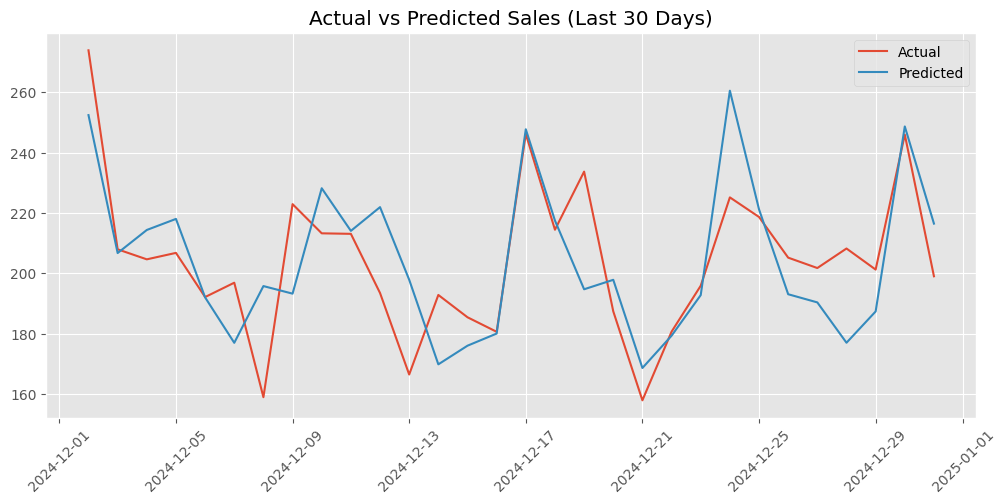

In [18]:
plt.figure(figsize=(12,5))
plt.plot(test['Date'], y_test.values, label="Actual")
plt.plot(test['Date'], y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Sales (Last 30 Days)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Predict Next 7 Days


future_days = 7
future_predictions = []

temp_df = df.copy()

for i in range(future_days):

    last_row = temp_df.iloc[-1]

    new_data = pd.DataFrame({
        'Promotion': [last_row['Promotion']],
        'DayOfWeek': [(last_row['DayOfWeek'] % 7) + 1],
        'lag_1': [last_row['Sales']],
        'lag_7': [temp_df['Sales'].iloc[-7]],
        'rolling_mean_7': [temp_df['Sales'].iloc[-7:].mean()]
    })

    pred = model.predict(new_data)[0]
    future_predictions.append(pred)

    # Append new predicted row
    new_row = last_row.copy()
    new_row['Sales'] = pred
    new_row['DayOfWeek'] = (last_row['DayOfWeek'] % 7) + 1

    temp_df = pd.concat([temp_df, pd.DataFrame([new_row])], ignore_index=True)

print("Next 7 Days Sales Prediction:")
print(future_predictions)

Next 7 Days Sales Prediction:
[np.float32(206.44844), np.float32(208.04842), np.float32(185.81667), np.float32(172.45099), np.float32(173.2807), np.float32(187.9445), np.float32(214.75993)]
